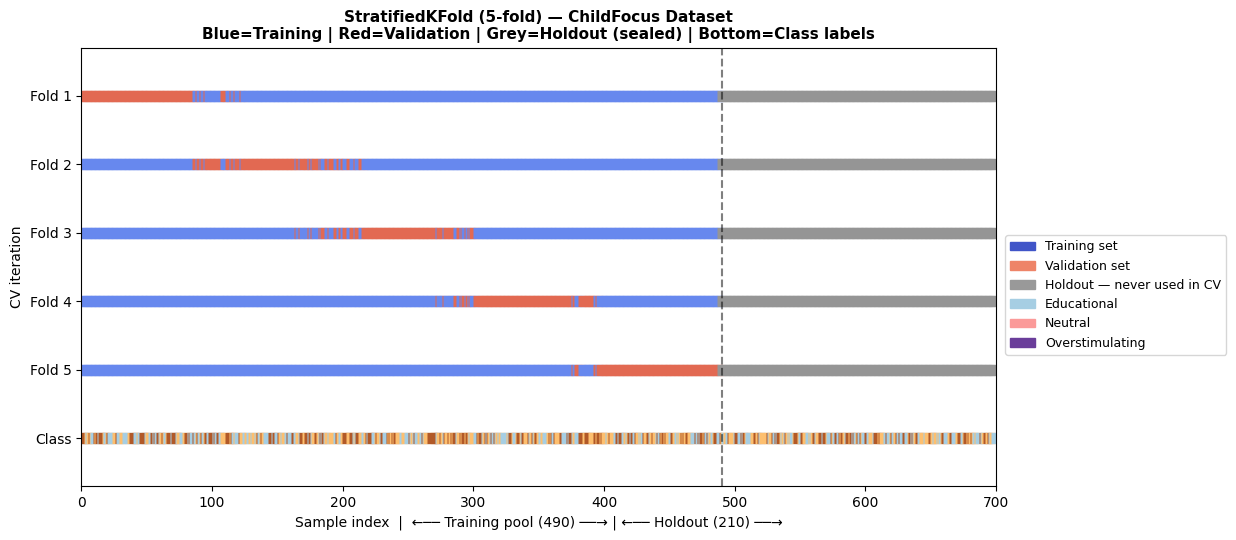

Saved: step6_final_figure.png


In [1]:
# STEP 6 — Complete research figure
# Add: class label strip at bottom + sealed holdout on the right

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from sklearn.model_selection import StratifiedKFold

N_TOTAL  = 700
N_TRAIN  = 490
N_TEST   = 210
N_SPLITS = 5

np.random.seed(42)
y_train = np.array([0]*161 + [1]*164 + [2]*165)
np.random.shuffle(y_train)
y_test = np.array([0]*69 + [1]*71 + [2]*70)
np.random.shuffle(y_test)

X_dummy = np.zeros((N_TRAIN, 1))
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=False)

cmap_cv   = plt.cm.coolwarm
cmap_data = plt.cm.Paired

fig, ax = plt.subplots(figsize=(13, 5.5))

# ── CV fold rows ───────────────────────────────────────────────────────────
for fold, (train_idx, val_idx) in enumerate(skf.split(X_dummy, y_train)):
    colors = np.full(N_TRAIN, np.nan)
    colors[val_idx]   = 1
    colors[train_idx] = 0

    # Training pool
    ax.scatter(range(N_TRAIN), [fold+0.5]*N_TRAIN,
               c=colors, marker="_", lw=8,
               cmap=cmap_cv, vmin=-0.2, vmax=1.2)

    # Holdout (grey, always the same — not part of CV)
    ax.scatter(range(N_TRAIN, N_TOTAL), [fold+0.5]*N_TEST,
               c=[0.5]*N_TEST, marker="_", lw=8,
               cmap=plt.cm.Greys, vmin=0, vmax=1)

# ── Class label strip (last row) ───────────────────────────────────────────
y_all = np.concatenate([y_train, y_test])
ax.scatter(range(N_TOTAL), [N_SPLITS+0.5]*N_TOTAL,
           c=y_all, marker="_", lw=8,
           cmap=cmap_data, vmin=0, vmax=2)

# ── Divider line ───────────────────────────────────────────────────────────
ax.axvline(N_TRAIN, color="black", lw=1.5, linestyle="--", alpha=0.5)

# ── Labels ─────────────────────────────────────────────────────────────────
yticklabels = [f"Fold {i+1}" for i in range(N_SPLITS)] + ["Class"]
ax.set(
    yticks=np.arange(N_SPLITS+1) + 0.5,
    yticklabels=yticklabels,
    xlabel="Sample index  |  ←── Training pool (490) ──→ | ←── Holdout (210) ──→",
    ylabel="CV iteration",
    xlim=[0, N_TOTAL],
    ylim=[N_SPLITS+1.2, -0.2],
)
ax.set_title("StratifiedKFold (5-fold) — ChildFocus Dataset\n"
             "Blue=Training | Red=Validation | Grey=Holdout (sealed) | Bottom=Class labels",
             fontsize=11, fontweight="bold")

legend = [
    Patch(color=cmap_cv(0.02), label="Training set"),
    Patch(color=cmap_cv(0.8),  label="Validation set"),
    Patch(color="#999999",     label="Holdout — never used in CV"),
    Patch(color=cmap_data(0.0),label="Educational"),
    Patch(color=cmap_data(0.4),label="Neutral"),
    Patch(color=cmap_data(0.8),label="Overstimulating"),
]
ax.legend(handles=legend, loc=(1.01, 0.3), fontsize=9, frameon=True)

plt.tight_layout()
fig.subplots_adjust(right=0.77)
plt.savefig("step6_final_figure.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: step6_final_figure.png")